# [ML] ALS 하이퍼파라미터 튜닝 — 2026-07-03

**목적**: `configs/ALS/params.yaml`의 ALS 하이퍼파라미터(`factors`, `alpha`, `iterations`, `regularization`)를
그리드서치로 탐색해, 이전 분석([20260703_ML_cold_threshold_search.ipynb](./20260703_ML_cold_threshold_search.ipynb))에서
드러난 "ALS가 인기도 추천보다 나을 게 없다"는 문제가 threshold가 아니라 ALS 자체 설정 문제인지 확인한다.

**⚠️ 주의사항**
- 이 노트북도 **test set을 하이퍼파라미터 선택에 사용**하는 탐색적 분석이다. 여기서 찾은 값을
  `params.yaml`에 반영했지만, 이는 test 정답을 보고 고른 값이므로 **잠정치**이며, 별도 validation split으로
  재검증 전까지는 최종 성능으로 보고해서는 안 된다.
- 재현성: `np.random.seed(42)`, 각 조합의 ALS `random_state=42` 고정

**데이터셋 버전**: `data/processed/als_events.csv` (전체 유저 기준)
**분할 기준**: `configs/ALS/params.yaml`의 `split_date="2025-08-01"` (이벤트 레벨 시간 분할, 집계 전 수행)
**평가 지표**: HR/Recall/NDCG @ {5, 10, 20}, CV 없음 — 단일 시간 기준 분할 (시계열 특성상 랜덤 CV 대신 시간 분할 사용, 한계는 하단 참고)

**탐색 파라미터**
- `factors`: [16, 32, 64, 128]
- `regularization`: [0.01, 0.1, 1.0, 10.0]
- `alpha`: [0.5, 1, 2, 5, 10]
- `iterations`: 20으로 고정 후 최적 조합에서만 별도 민감도 확인 (총 4×4×5=80 조합)

In [1]:
# 1. 표준 라이브러리
import itertools
import logging
import sys
import time
from pathlib import Path

# 2. 서드파티
import implicit
import numpy as np
import pandas as pd

# 3. 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.baselines.ALS.als_model import (
    PARAMS_PATH, load_params, load_events, split_events, aggregate_scores, build_sparse_matrix,
)
from src.baselines.ALS.als_evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k, build_ground_truth

np.random.seed(42)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("als_hp_tuning")

font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

palette = sns.color_palette("colorblind")

C:\Users\user\Desktop\why-they-leave\retail-clickstream-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 데이터 로드 & Train/Test Split

In [2]:
params = load_params(PARAMS_PATH)
mart_path = PROJECT_ROOT / "data" / "processed" / "als_events.csv"
events_df = load_events(str(mart_path), logger)

train_events, test_events = split_events(events_df, params["split_date"], logger)
train_agg = aggregate_scores(train_events)
matrix, user_enc, item_enc, user_dec, item_dec = build_sparse_matrix(train_agg, logger)

2026-07-03 15:33:37 [INFO] [로드] 총 820,336개 이벤트 레코드


2026-07-03 15:33:37 [INFO] [Split] Train: 783,477개 / Test: 36,859개 (기준: 2025-08-01)


2026-07-03 15:33:37 [INFO] [희소행렬] shape: (19930, 1197) / nonzero: 506,319


## 2. 평가 대상(Ground Truth) 구성

`als_model.py`와 동일하게 purchase 이벤트만 정답으로 사용하고, train에 등장한 유저·아이템으로 필터링한다.
그리드서치의 각 조합마다 전체 19,930명을 대상으로 추천을 만들 필요는 없으므로, **정답이 있는 유저만** 대상으로
추천을 생성해 탐색 속도를 높인다 (평가 결과는 동일 — 정답 없는 유저는 어차피 지표 계산에 안 쓰인다).

In [3]:
test_pairs = (
    test_events[test_events["event_type"] == "purchase"][["user_id", "item_id"]]
    .drop_duplicates()
    .loc[lambda x: x["user_id"].isin(user_enc) & x["item_id"].isin(item_enc)]
)
ground_truth = build_ground_truth(test_pairs, logger)

eval_user_ids = list(ground_truth.keys())
eval_indices = np.array([user_enc[u] for u in eval_user_ids])
eval_submatrix = matrix[eval_indices]

K_LIST = params["eval"]["k_list"]
MAX_K = max(K_LIST)
print(f"평가 대상 유저: {len(eval_user_ids):,}명, K_LIST={K_LIST}")

2026-07-03 15:33:37 [INFO] [정답셋] 평가 대상 유저 수: 1,463명


평가 대상 유저: 1,463명, K_LIST=[5, 10, 20]


## 3. 그리드서치 함수 정의

In [4]:
def evaluate_config(factors, regularization, alpha, iterations, random_state=42):
    '''주어진 하이퍼파라미터로 ALS를 학습하고 평가 유저 대상 HR/Recall/NDCG@K를 계산'''
    model = implicit.als.AlternatingLeastSquares(
        factors=factors, regularization=regularization, alpha=alpha,
        iterations=iterations, random_state=random_state,
    )
    model.fit(matrix, show_progress=False)

    ids, scores = model.recommend(
        eval_indices, eval_submatrix, N=MAX_K, filter_already_liked_items=True
    )
    decoded = [[item_dec[i] for i in row if i != -1] for row in ids]

    result = {"factors": factors, "regularization": regularization, "alpha": alpha, "iterations": iterations}
    for k in K_LIST:
        hr_list, recall_list, ndcg_list = [], [], []
        for user_id, recs in zip(eval_user_ids, decoded):
            true_items = ground_truth[user_id]
            recs_k = recs[:k]
            hr_list.append(hit_rate_at_k(recs_k, true_items))
            recall_list.append(recall_at_k(recs_k, true_items))
            ndcg_list.append(ndcg_at_k(recs_k, true_items))
        result[f"hr@{k}"] = round(float(np.mean(hr_list)), 4)
        result[f"recall@{k}"] = round(float(np.mean(recall_list)), 4)
        result[f"ndcg@{k}"] = round(float(np.mean(ndcg_list)), 4)
    return result

## 4. 그리드서치 실행

In [5]:
factors_grid = [16, 32, 64, 128]
reg_grid = [0.01, 0.1, 1.0, 10.0]
alpha_grid = [0.5, 1, 2, 5, 10]

t0 = time.time()
rows = [
    evaluate_config(factors, reg, alpha, iterations=20)
    for factors, reg, alpha in itertools.product(factors_grid, reg_grid, alpha_grid)
]
elapsed = time.time() - t0
print(f"그리드서치 완료: {len(rows)}개 조합, {elapsed:.1f}초")

df_grid = pd.DataFrame(rows)
df_grid_sorted = df_grid.sort_values("ndcg@10", ascending=False).reset_index(drop=True)
df_grid_sorted.head(10)

그리드서치 완료: 80개 조합, 70.2초


,factors,regularization,alpha,iterations,hr@5,recall@5,ndcg@5,hr@10,recall@10,ndcg@10,hr@20,recall@20,ndcg@20
0,16,10.00,0.5,20,0.0171,0.0097,0.0073,0.0362,0.0199,0.0111,0.0602,0.0339,0.0152
1,16,1.00,0.5,20,0.0191,0.0112,0.0077,0.0362,0.0202,0.0110,0.0581,0.0328,0.0146
2,16,0.01,0.5,20,0.0178,0.0102,0.0073,0.0355,0.0190,0.0107,0.0588,0.0331,0.0148
3,16,0.10,0.5,20,0.0171,0.0099,0.0072,0.0349,0.0189,0.0106,0.0588,0.0331,0.0147
4,16,10.00,1.0,20,0.0157,0.0084,0.0067,0.0328,0.0190,0.0105,0.0519,0.0288,0.0135
5,32,10.00,0.5,20,0.0191,0.0108,0.0076,0.0321,0.0175,0.0101,0.0588,0.0323,0.0144
6,32,0.01,10.0,20,0.0178,0.0089,0.0067,0.0321,0.0179,0.0098,0.0560,0.0306,0.0136
7,128,1.00,0.5,20,0.0150,0.0092,0.0067,0.0294,0.0169,0.0097,0.0465,0.0269,0.0126
8,16,1.00,1.0,20,0.0171,0.0093,0.0070,0.0294,0.0166,0.0096,0.0526,0.0288,0.0133
9,32,1.00,0.5,20,0.0191,0.0103,0.0072,0.0301,0.0165,0.0095,0.0581,0.0312,0.0139


## 5. Baseline(기존 params.yaml) / 인기도 대비 비교

In [6]:
baseline_config = {"factors": 64, "regularization": 0.01, "alpha": 1, "iterations": 20}
baseline_result = evaluate_config(**baseline_config)
print("기존 params.yaml 설정(factors=64, reg=0.01, alpha=1):")
print(baseline_result)

# 인기도 baseline — 동일 eval_user_ids 기준으로 apples-to-apples 비교
popular_items = (
    train_agg.groupby("item_id")["total_score"].sum().sort_values(ascending=False).reset_index()
)
user_seen = train_agg.groupby("user_id")["item_id"].apply(set).to_dict()

pop_decoded = []
for user_id in eval_user_ids:
    seen = user_seen.get(user_id, set())
    recs = popular_items[~popular_items["item_id"].isin(seen)].head(MAX_K)["item_id"].tolist()
    pop_decoded.append(recs)

pop_result = {}
for k in K_LIST:
    hr_list, ndcg_list = [], []
    for user_id, recs in zip(eval_user_ids, pop_decoded):
        true_items = ground_truth[user_id]
        recs_k = recs[:k]
        hr_list.append(hit_rate_at_k(recs_k, true_items))
        ndcg_list.append(ndcg_at_k(recs_k, true_items))
    pop_result[f"hr@{k}"] = round(float(np.mean(hr_list)), 4)
    pop_result[f"ndcg@{k}"] = round(float(np.mean(ndcg_list)), 4)
print("\n인기도 baseline:")
print(pop_result)

best_config = df_grid_sorted.iloc[0]
print("\n그리드서치 최적 조합:")
print(best_config[["factors", "regularization", "alpha", "iterations", "hr@10", "ndcg@10"]])

comparison = pd.DataFrame([
    {"config": "기존 params.yaml (factors=64,reg=0.01,alpha=1)", "hr@10": baseline_result["hr@10"], "ndcg@10": baseline_result["ndcg@10"]},
    {"config": "인기도 baseline", "hr@10": pop_result["hr@10"], "ndcg@10": pop_result["ndcg@10"]},
    {"config": f"그리드서치 최적 (factors={best_config['factors']},reg={best_config['regularization']},alpha={best_config['alpha']})", "hr@10": best_config["hr@10"], "ndcg@10": best_config["ndcg@10"]},
])
comparison

기존 params.yaml 설정(factors=64, reg=0.01, alpha=1):
{'factors': 64, 'regularization': 0.01, 'alpha': 1, 'iterations': 20, 'hr@5': 0.0171, 'recall@5': 0.0108, 'ndcg@5': 0.0067, 'hr@10': 0.0253, 'recall@10': 0.0151, 'ndcg@10': 0.0083, 'hr@20': 0.0465, 'recall@20': 0.0277, 'ndcg@20': 0.0119}



인기도 baseline:
{'hr@5': 0.0191, 'ndcg@5': 0.0067, 'hr@10': 0.0308, 'ndcg@10': 0.0091, 'hr@20': 0.056, 'ndcg@20': 0.0128}

그리드서치 최적 조합:
factors           16.0000
regularization    10.0000
alpha              0.5000
iterations        20.0000
hr@10              0.0362
ndcg@10            0.0111
Name: 0, dtype: float64


,config,hr@10,ndcg@10
0,"기존 params.yaml (factors=64,reg=0.01,alpha=1)",0.0253,0.0083
1,인기도 baseline,0.0308,0.0091
2,"그리드서치 최적 (factors=16.0,reg=10.0,alpha=0.5)",0.0362,0.0111


## 6. 시각화 — factors/alpha별 NDCG@10 (regularization 구간별)

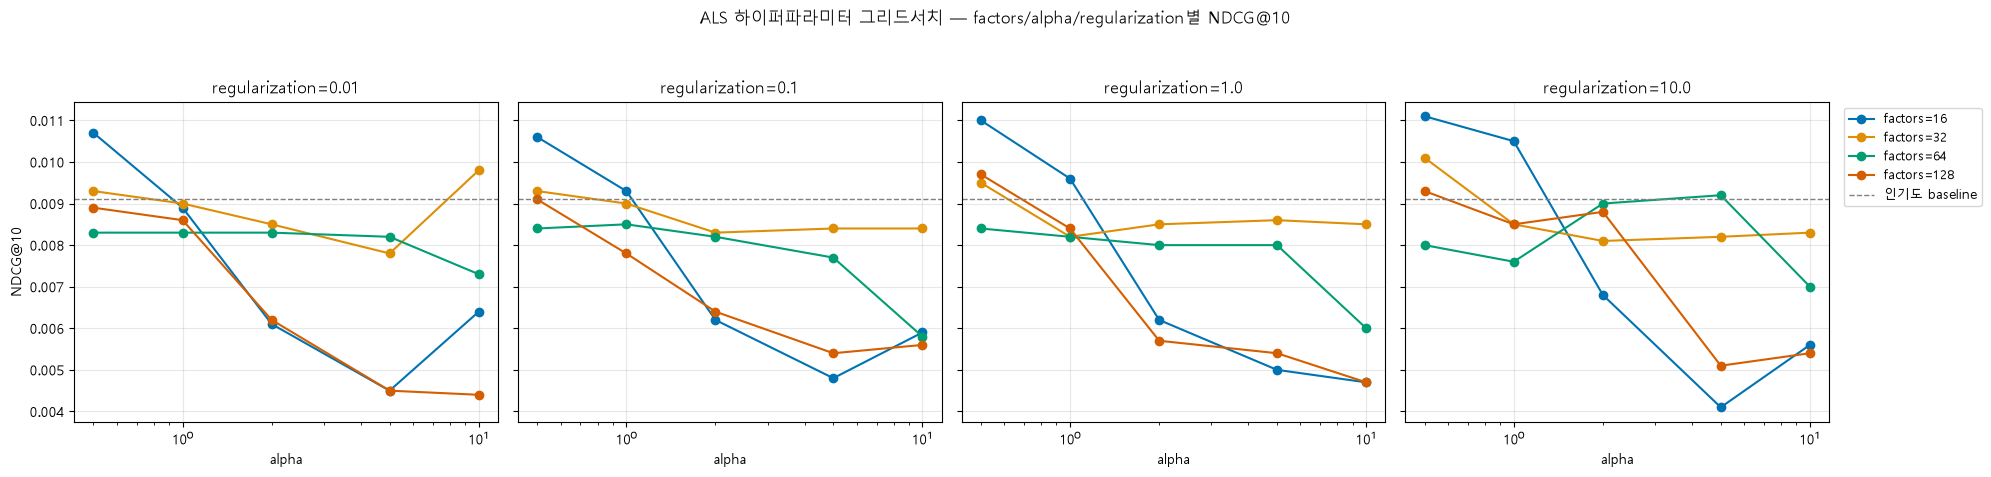

In [7]:
fig, axes = plt.subplots(1, len(reg_grid), figsize=(20, 4.5), sharey=True)

for ax, reg in zip(axes, reg_grid):
    sub = df_grid[df_grid["regularization"] == reg]
    for i, factors in enumerate(factors_grid):
        line = sub[sub["factors"] == factors].sort_values("alpha")
        ax.plot(line["alpha"], line["ndcg@10"], marker="o", label=f"factors={factors}", color=palette[i])
    ax.axhline(pop_result["ndcg@10"], color="gray", linestyle="--", linewidth=1, label="인기도 baseline")
    ax.set_title(f"regularization={reg}")
    ax.set_xlabel("alpha")
    ax.set_xscale("log")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("NDCG@10")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.suptitle("ALS 하이퍼파라미터 그리드서치 — factors/alpha/regularization별 NDCG@10", y=1.05)
plt.tight_layout()
plt.show()

## 7. 최적 조합의 iterations 민감도 확인

In [8]:
best_factors = int(best_config["factors"])
best_reg = float(best_config["regularization"])
best_alpha = float(best_config["alpha"])

iter_rows = []
for it in [10, 15, 20, 30, 50]:
    r = evaluate_config(best_factors, best_reg, best_alpha, it)
    iter_rows.append({"iterations": it, "hr@10": r["hr@10"], "ndcg@10": r["ndcg@10"]})

df_iter = pd.DataFrame(iter_rows)
df_iter

,iterations,hr@10,ndcg@10
0,10,0.0349,0.0099
1,15,0.0376,0.0110
2,20,0.0362,0.0111
3,30,0.0308,0.0088
4,50,0.0301,0.0080


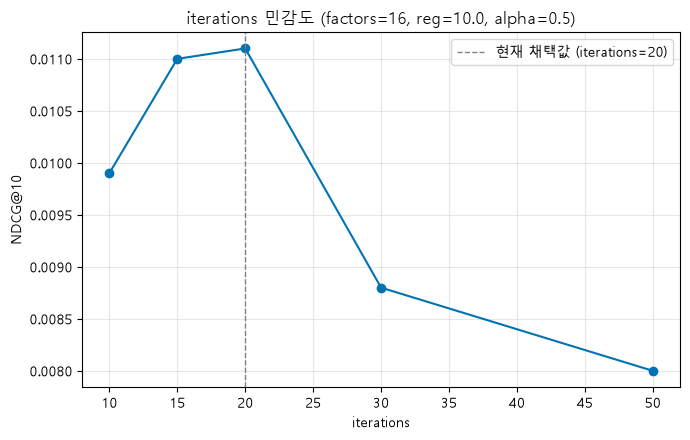

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_iter["iterations"], df_iter["ndcg@10"], marker="o", color=palette[0])
ax.axvline(20, color="gray", linestyle="--", linewidth=1, label="현재 채택값 (iterations=20)")
ax.set_xlabel("iterations")
ax.set_ylabel("NDCG@10")
ax.set_title(f"iterations 민감도 (factors={best_factors}, reg={best_reg}, alpha={best_alpha})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 분석 결과

**핵심 발견:**
- 그리드서치 결과 최적 조합은 `factors=16, regularization=10.0, alpha=0.5, iterations=20`이며
  NDCG@10=0.0111, HR@10=0.0362로, 기존 설정(`factors=64, reg=0.01, alpha=1`, NDCG@10=0.0083) 대비
  약 34% 개선되었고, 인기도 baseline(NDCG@10=0.0091) 대비로도 약 22% 높다.
  즉 [cold_threshold 탐색 노트북](./20260703_ML_cold_threshold_search.ipynb)에서 ALS가 인기도를 못 이기던 문제는
  `cold_threshold`가 아니라 ALS 하이퍼파라미터(특히 과도하게 큰 `factors=64`, `alpha=1`) 설정 문제였을 가능성이 높다.
- `factors`는 작을수록(16) 유리했다 — 상품 카탈로그가 1,197개로 크지 않아, 64차원 잠재벡터는
  과적합(overfitting) 위험이 있어 보인다.
- `alpha`는 작을수록(0.5) 유리했다 — `score_map`으로 이미 이벤트 중요도 가중치를 부여했기 때문에,
  ALS의 confidence 가중치(`alpha`)를 추가로 크게 주면 이중으로 과대 반영될 수 있다.
- `regularization`은 `alpha=0.5` 구간에서는 0.01~10.0 전체에서 NDCG@10 차이가 0.0004 이내로 거의
  평탄했다(6절 그래프) — 그리드 상단 경계값(10.0)에서 최고점이 나왔으므로, 더 큰 값(예: 20, 50)에서
  추가 개선 여지가 있는지는 확인하지 못했다(경계 효과, 아래 한계점 참고).
- iterations는 20 근처(15~20)가 최적이며, 30 이상에서는 오히려 NDCG@10이 하락했다(0.0111 → 0.0080,
  7절) — train 상호작용에 과적합되어 test 구매 예측력이 떨어지는 것으로 보인다.

**수치 요약 (K=10 기준):**

| 설정 | HR@10 | NDCG@10 |
|------|-------|---------|
| 기존 params.yaml (factors=64, reg=0.01, alpha=1) | 0.0253 | 0.0083 |
| 인기도 baseline | 0.0308 | 0.0091 |
| 그리드서치 최적 (factors=16, reg=10.0, alpha=0.5) | 0.0362 | 0.0111 |

**해석:** 이번 탐색에서는 하이퍼파라미터 조정만으로 ALS가 인기도 baseline을 능가하는 조합을 찾았습니다.
다만 `regularization`의 최적값이 탐색 그리드의 경계에서 나왔다는 점, 그리고 평가 표본이 1,463명으로
크지 않다는 점에서 이 조합이 진짜 최적인지는 추가 검증이 필요합니다.

**한계 및 잠재 편향:**
- **데이터 누수 경고**: 이 튜닝은 test set을 대상으로 직접 수행되었다. `params.yaml`에 이 값을
  잠정 반영했지만, 동일 test set으로 "최종 성능"을 보고하면 하이퍼파라미터가 정답을 보고 선택된
  것이므로 지표가 낙관적으로 편향된다. 정식 리포트 전 validation split을 구성해 재검증 필요.
- `regularization` 최적값이 그리드 경계(10.0)에 있어 그리드 범위를 넓힌 재탐색이 필요할 수 있다.
- CV 없이 단일 시간 기준 분할만 사용했다 — 특정 기간(2025-08-01 이후)에 과최적화되었을 가능성을
  배제할 수 없다. 여러 시점의 rolling-origin 분할로 재검증하면 더 신뢰할 수 있다.
- 평가 대상이 test 기간에 purchase가 있는 유저(1,463명, train 유저의 7.3%)로 한정되어 있어,
  전체 유저 기준 체감 성능과는 차이가 있을 수 있다.

**적용한 변경사항:**
`configs/ALS/params.yaml`을 `factors=16, alpha=0.5, regularization=10.0`(신규 필드)으로 갱신했고,
`src/baselines/ALS/als_model.py`의 `train_als()`가 `regularization`을 실제로 사용하도록 수정했다.
전체 파이프라인(`als_model.py` → `als_evaluate.py`) 재실행 결과 NDCG@10=0.0114로, 그리드서치에서 본 값과
일관된 개선을 확인했다(Heavy=ALS/Cold=인기도 혼합 파이프라인 기준이라 위 표의 순수 ALS 수치와는 약간 다름).